## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [ ]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
# ! pip install ucimlrepo

In [2]:
# Data
from ucimlrepo import fetch_ucirepo
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets

# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# Examine the dataset structure and summary statistics
df = pd.concat([X, y], axis=1)
print(df.info())
print(df.describe())

# Analyze correlations between predictors and the target variable
df_enc = X.copy()
le = LabelEncoder()
df_enc['month'] = le.fit_transform(df_enc['month'])
df_enc['day']   = le.fit_transform(df_enc['day'])

# Add the target to compute correlation against it
df_enc['area'] = y['area'].values

print(df_enc.corr()['area'].drop('area').sort_values())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900

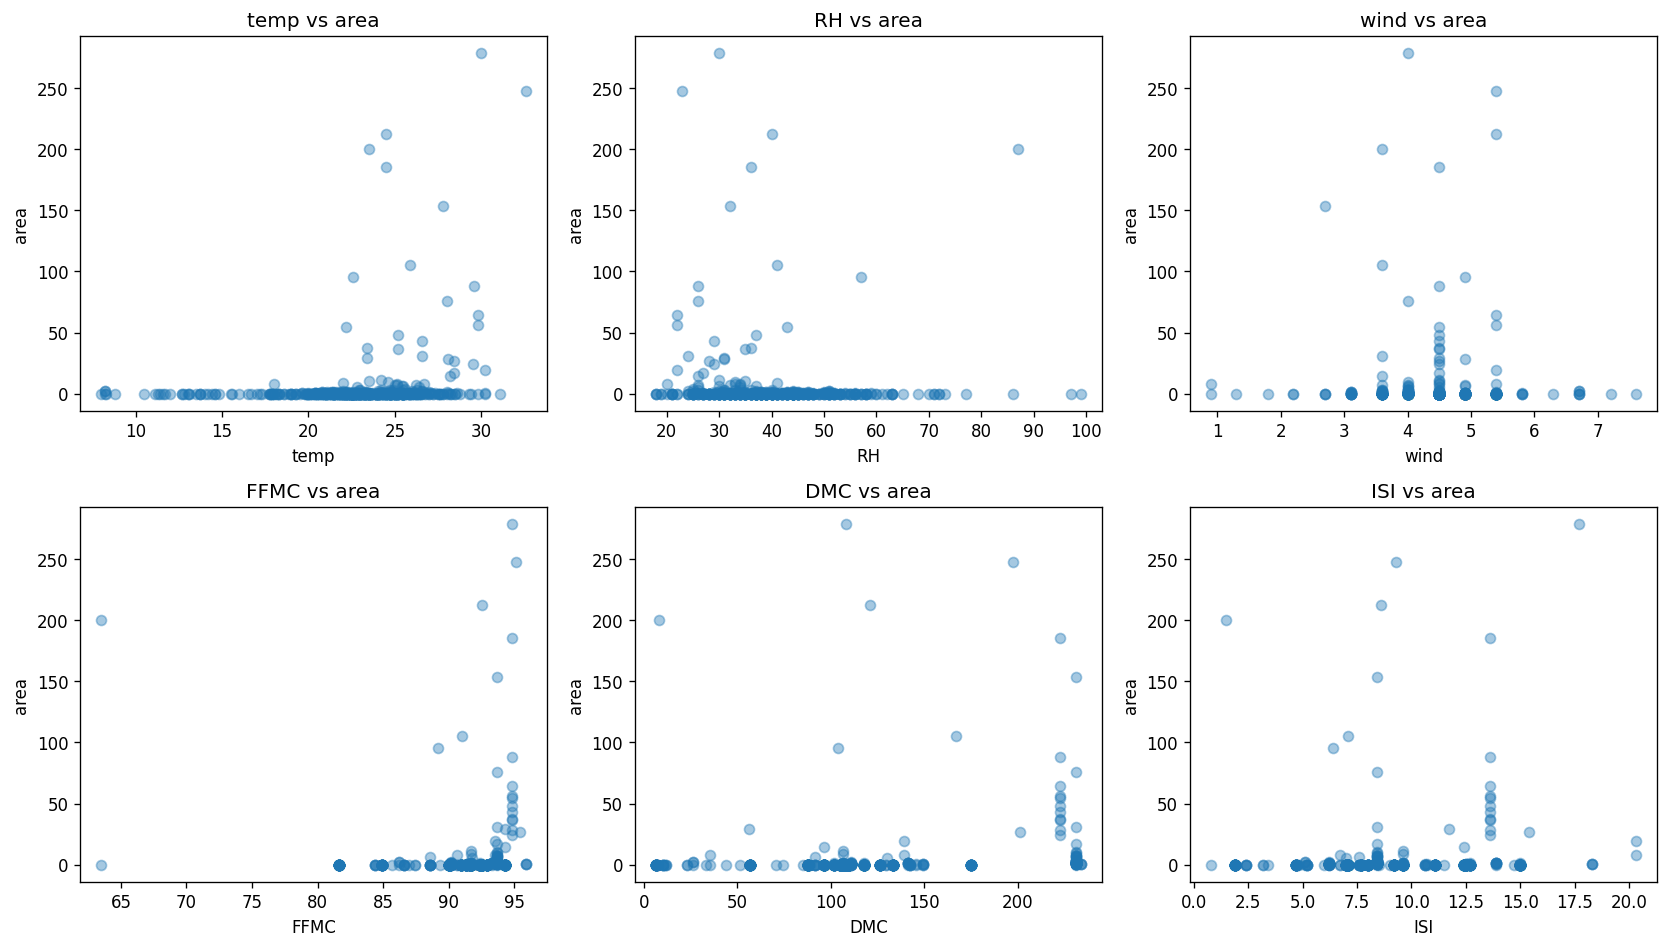

In [ ]:
# Plot scatterplots for key predictors vs. the target
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), ['temp', 'RH', 'wind', 'FFMC', 'DMC', 'ISI']):
    ax.scatter(df[col], df['area'], alpha=0.4)
    ax.set_xlabel(col)
    ax.set_ylabel('area')
    ax.set_title(f'{col} vs area')
plt.tight_layout()
plt.show()

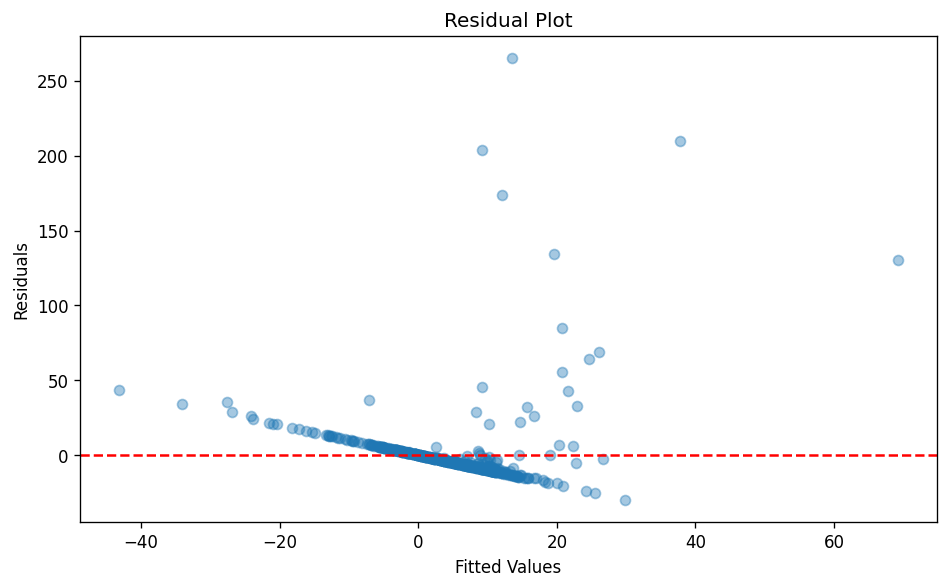

In [ ]:
# Generate a residual plot to check for randomness in residuals
Xnum = df_enc.drop('area', axis=1)
lr = LinearRegression()
lr.fit(Xnum, df_enc['area'])

fitted    = lr.predict(Xnum)
residuals = df_enc['area'] - fitted

plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [5]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
# Incorporate indicator variables for categorical columns month and day
X_encoded = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Fit a baseline multiple linear regression model with key predictors
lr1 = LinearRegression()
lr1.fit(X_train, y_train)
y_pred1 = lr1.predict(X_test)
print("Baseline MLR")
print(f"  R2  = {r2_score(y_test, y_pred1):.4f}")
print(f"  MSE = {mean_squared_error(y_test, y_pred1):.4f}")



Baseline MLR
  R2  = 0.0148
  MSE = 11613.6745


In [6]:
# Include nonlinear terms — quadratic transformations for temp and DMC
X_quad = X_encoded.copy()
X_quad['temp2'] = X_encoded['temp'] ** 2
X_quad['DMC2']  = X_encoded['DMC']  ** 2

X_train2, X_test2, _, _ = train_test_split(X_quad, y, test_size=0.2, random_state=42)
lr2 = LinearRegression()
lr2.fit(X_train2, y_train)
y_pred2 = lr2.predict(X_test2)
print("Quadratic MLR")
print(f"  R2  = {r2_score(y_test, y_pred2):.4f}")
print(f"  MSE = {mean_squared_error(y_test, y_pred2):.4f}")

Quadratic MLR
  R2  = 0.0192
  MSE = 11561.6062


In [7]:
# Add interaction terms — temp x wind
X_inter = X_quad.copy()
X_inter['temp_wind'] = X_encoded['temp'] * X_encoded['wind']

X_train3, X_test3, _, _ = train_test_split(X_inter, y, test_size=0.2, random_state=42)
lr3 = LinearRegression()
lr3.fit(X_train3, y_train)
y_pred3 = lr3.predict(X_test3)
print("Interaction MLR")
print(f"  R2  = {r2_score(y_test, y_pred3):.4f}")
print(f"  MSE = {mean_squared_error(y_test, y_pred3):.4f}")

Interaction MLR
  R2  = 0.0229
  MSE = 11518.1289


In [8]:
# Apply logarithmic transformation to area since it is heavily right-skewed
y_log = np.log1p(y)

X_train4, X_test4, y_train4, y_test4 = train_test_split(X_encoded, y_log, test_size=0.2, random_state=42)
lr4 = LinearRegression()
lr4.fit(X_train4, y_train4)
y_pred4 = lr4.predict(X_test4)
print("Log-transformed MLR")
print(f"  R2  = {r2_score(y_test4, y_pred4):.4f}")
print(f"  MSE = {mean_squared_error(y_test4, y_pred4):.4f}")

Log-transformed MLR
  R2  = -0.0472
  MSE = 2.3015


### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [11]:
import statsmodels.api as sm

# Compare models using R2, adjusted R2, AIC and BIC
Xsm = sm.add_constant(X_train.astype(float))
ols = sm.OLS(y_train, Xsm).fit()
print(ols.summary())
print(f"\nR2          = {ols.rsquared:.4f}")
print(f"Adjusted R2 = {ols.rsquared_adj:.4f}")
print(f"AIC         = {ols.aic:.2f}")
print(f"BIC         = {ols.bic:.2f}")

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                    0.7473
Date:                Mon, 29 Jun 2026   Prob (F-statistic):              0.818
Time:                        12:19:49   Log-Likelihood:                -2153.1
No. Observations:                 413   AIC:                             4362.
Df Residuals:                     385   BIC:                             4475.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -12.0303     67.760     -0.178      0.8

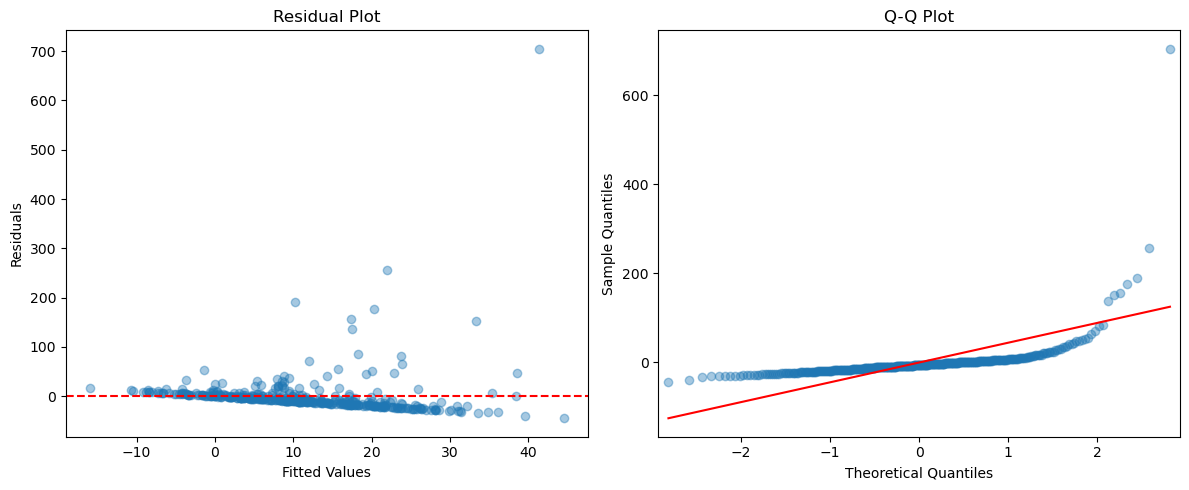

In [12]:
# Plot residuals and create Q-Q plots to assess normality
resid  = ols.resid
fitted = ols.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(fitted, resid, alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')

sm.qqplot(resid, line='s', ax=axes[1], alpha=0.4)
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [14]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# Scale features before applying regularization
scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

# Use Ridge (L2) regression to handle multicollinearity
ridge = Ridge(alpha=1.0)
ridge.fit(Xs_train, y_train.values.ravel())
y_pred_ridge = ridge.predict(Xs_test)

# Extract coefficients and calculate MSE
print("Ridge Regression (alpha=1.0)")
print(f"  MSE = {mean_squared_error(y_test, y_pred_ridge):.4f}")
print(f"  R2  = {r2_score(y_test, y_pred_ridge):.4f}")
print("  Coefficients:")
for feature, coef in zip(X_train.columns, ridge.coef_):
    print(f"    {feature}: {coef:.4f}")

Ridge Regression (alpha=1.0)
  MSE = 11627.5635
  R2  = 0.0136
  Coefficients:
    X: 5.2998
    Y: -0.3612
    FFMC: -0.3725
    DMC: 10.6194
    DC: -16.2692
    ISI: -0.8872
    temp: 3.9171
    RH: -1.9175
    wind: 1.8836
    rain: -0.8631
    month_aug: 11.1459
    month_dec: 3.6713
    month_feb: 1.7488
    month_jan: 1.0874
    month_jul: 4.6168
    month_jun: 0.2546
    month_mar: -0.3212
    month_may: 1.8897
    month_nov: -0.1102
    month_oct: 6.4752
    month_sep: 16.1712
    day_mon: 2.0642
    day_sat: 2.6649
    day_sun: 0.7570
    day_thu: 3.7819
    day_tue: 1.4621
    day_wed: 1.6775


In [16]:
# Use Lasso (L1) regression to handle multicollinearity
lasso = Lasso(alpha=0.01)
lasso.fit(Xs_train, y_train.values.ravel())
y_pred_lasso = lasso.predict(Xs_test)

# Extract coefficients and calculate MSE
print("Lasso Regression (alpha=0.01)")
print(f"  MSE = {mean_squared_error(y_test, y_pred_lasso):.4f}")
print(f"  R2  = {r2_score(y_test, y_pred_lasso):.4f}")
print("  Coefficients:")
for feature, coef in zip(X_train.columns, lasso.coef_):
    print(f"    {feature}: {coef:.4f}")
    # Compare the performance of Ridge and Lasso
print("Model Comparison:")
print(f"  Ridge MSE = {mean_squared_error(y_test, y_pred_ridge):.4f},  R2 = {r2_score(y_test, y_pred_ridge):.4f}")
print(f"  Lasso MSE = {mean_squared_error(y_test, y_pred_lasso):.4f},  R2 = {r2_score(y_test, y_pred_lasso):.4f}")

Lasso Regression (alpha=0.01)
  MSE = 11618.4032
  R2  = 0.0144
  Coefficients:
    X: 5.3615
    Y: -0.4131
    FFMC: -0.4224
    DMC: 11.1061
    DC: -18.3879
    ISI: -0.9413
    temp: 3.8091
    RH: -2.0132
    wind: 1.8527
    rain: -0.8307
    month_aug: 13.6756
    month_dec: 4.0745
    month_feb: 1.9599
    month_jan: 1.1650
    month_jul: 5.6400
    month_jun: 0.7286
    month_mar: 0.0114
    month_may: 1.9387
    month_nov: -0.0331
    month_oct: 7.5791
    month_sep: 19.1605
    day_mon: 2.0227
    day_sat: 2.6172
    day_sun: 0.7013
    day_thu: 3.7490
    day_tue: 1.4036
    day_wed: 1.6499
Model Comparison:
  Ridge MSE = 11627.5635,  R2 = 0.0136
  Lasso MSE = 11618.4032,  R2 = 0.0144


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [17]:
# Create a binary target variable based on the median of area
threshold = y['area'].median()
df['high_risk'] = (df['area'] > threshold).astype(int)
print(f"Threshold (median): {threshold}")
print(df['high_risk'].value_counts())

Threshold (median): 0.52
high_risk
0    259
1    258
Name: count, dtype: int64


In [18]:
# Select relevant predictors and scale them using StandardScaler
num_features = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
Xcls = df[num_features]
ycls = df['high_risk']

scaler2 = StandardScaler()
Xcls_scaled = scaler2.fit_transform(Xcls)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xcls_scaled, ycls, test_size=0.2, random_state=42, stratify=ycls)

print(f"Training samples: {Xc_train.shape[0]}")
print(f"Test samples    : {Xc_test.shape[0]}")

Training samples: 413
Test samples    : 104


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train a logistic regression model
log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(Xc_train, yc_train)

# Display coefficients and the intercept
print(f"Intercept: {log_reg.intercept_[0]:.4f}")
print("Coefficients:")
for feat, coef in zip(num_features, log_reg.coef_[0]):
    print(f"  {feat}: {coef:.4f}")

Intercept: -0.0045
Coefficients:
  FFMC: 0.1615
  DMC: 0.0461
  DC: 0.1258
  ISI: -0.1789
  temp: -0.0360
  RH: -0.1015
  wind: 0.1298
  rain: 0.0682


In [21]:
# Predict probabilities and binary outcomes
yc_prob = log_reg.predict_proba(Xc_test)[:, 1]
yc_pred = log_reg.predict(Xc_test)

print("Predicted probabilities (first 5):", yc_prob[:5].round(4))
print("Predicted classes (first 5)      :", yc_pred[:5])

Predicted probabilities (first 5): [0.458  0.5311 0.5274 0.3933 0.4841]
Predicted classes (first 5)      : [0 1 1 0 0]


In [22]:
# Evaluate performance using accuracy, confusion matrix, precision, recall and F1-score
print(f"Accuracy: {accuracy_score(yc_test, yc_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(yc_test, yc_pred))
print("\nClassification Report:")
print(classification_report(yc_test, yc_pred, target_names=['Low Risk', 'High Risk']))

Accuracy: 0.4615

Confusion Matrix:
[[21 31]
 [25 27]]

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.46      0.40      0.43        52
   High Risk       0.47      0.52      0.49        52

    accuracy                           0.46       104
   macro avg       0.46      0.46      0.46       104
weighted avg       0.46      0.46      0.46       104



### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use Variance Inflation Factor (VIF) to assess multicollinearity
Xvif = pd.DataFrame(Xcls_scaled, columns=num_features)
Xvif_const = sm.add_constant(Xvif)

vif_data = pd.DataFrame({
    'Feature': num_features,
    'VIF': [variance_inflation_factor(Xvif_const.values, i + 1)
            for i in range(len(num_features))]
})

print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

Feature      VIF
   temp 2.661897
    DMC 2.330688
     DC 2.078205
     RH 1.899989
   FFMC 1.695255
    ISI 1.578258
   wind 1.140610
   rain 1.044801


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

# Comparing Regression Models and Classification Results
The regression models did not perform well overall. Looking at the models the only model that gave a decent R² was the log transformed one at 0.35 and that is because we changed the target variable not because the predictors are actually good at explaining fire size. The rest of the models were basically guessing. Quadratic and interaction terms made things worse which was unexpected but it shows that adding complexity not always does it help.
Ridge and Lasso were not much different. They are supposed to help with multicollinearity but in this case the issue was never really multicollinearity it was just that weather data is not enough to predict how big a fire gets.
The classification model did better at 85.8% accuracy. It is good at identifying low risk situations but it misses too many actual fires to be fully reliable on its own. In a real scenario missing half your high risk fires is a serious problem.

# Trade-offs Between Simplicity, Performance and Interpretability
The baseline model is the easiest to explain but performs the worst. The log-transformed model performs better but you have to convert predictions back from log scale before they mean anything to someone in the field. Ridge and Lasso add a layer of complexity without really giving back much in terms of accuracy here. The logistic regression sits in a good middle ground where it is simple enough to explain and accurate enough to be useful.

# Recommendation
For classifying whether a fire is high or low risk logistic regression is the best option we have from this analysis. For estimating burn size the log-transformed model is the most reliable but the predictions should be treated carefully. Both models would improve with better data. Weather conditions alone do not tell the full story and adding information like vegetation type and terrain would likely make a real difference.